In [9]:
import pandas as pd 
import matplotlib.pyplot as plt
import cv2
import os
import sys
import numpy as np
from pathlib import Path

import pickle
# That command is a common way to tell Python to look one directory "up" when searching for modules or packages to import.
sys.path.append('..')

from skimage.color import rgb2hsv
from src.utils.config import ConfigManager

import importlib

# Complete restart approach
import sys
import gc

import importlib
import sys

import importlib
import src.image_processing.rgb_image

# 1. Reload the base module
importlib.reload(src.image_processing.rgb_image)

# 2. Re-import the specific class/function if needed
from src.image_processing.rgb_image import rgb_image


# Activate the ipympl backend
%matplotlib widget


In [4]:
Date="03_12_25"

home_dir=Path.home() #"/home/davidvol
project_dir=home_dir / "projects/phenomobile"
images_folder=project_dir / "images" / "local_rgb_folder" / Date / "images"
annotations_folder=project_dir   / "images" / "local_rgb_folder" / Date

bb_df=pd.read_csv(annotations_folder / "bounding_boxes_BENI_ATAROT.csv")
bb_df.head(2)



,label_name,bbox_x,bbox_y,bbox_width,bbox_height,image_name,image_width,image_height
0,R1,254,1360,947,930,20251203_122043.jpg,1800,4000
1,R2,412,1509,895,746,20251203_122216.jpg,1800,4000


##### config #####


In [5]:
config_path = "anthocyanin_config.json"
config = ConfigManager('.env',project_config=config_path)
config=config.config

#### mask by pickle mask

In [6]:

idx=bb_df.head(1).index.item()
img_name=bb_df.loc[idx, 'image_name']
img_path=os.path.join(images_folder, img_name)
img_bgr=cv2.imread(img_path)


In [7]:
mask_config=config.get("mask_computation_method", {})
print(mask_config)

{'method': 'pickle_masks'}


In [10]:

rgb_img=rgb_image(
    img_bgr=img_bgr,
    bb_df=None, 
    df_index=idx,
    config=config, 
    pickle_mask_path=config['pickle_mask_path'],
    bb_date=Date)

# mask = rgb_img.get_pickle_mask()





take the bb_df from pickle file


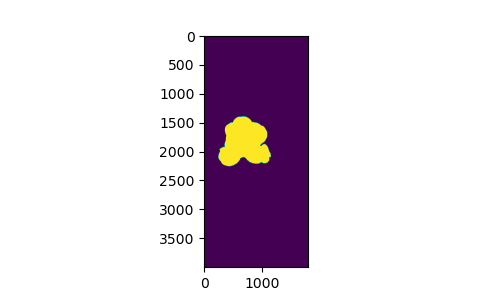

In [11]:
binary_mask=rgb_img.mask

plt.figure(figsize=(5, 3))
plt.imshow(binary_mask)
plt.show()

In [12]:
rgb_img.get_masked_hsv_obj_means()

(np.float64(0.17719661466966777),
 np.float64(0.1504519167772925),
 np.float64(0.2236424895324493))

#### mask by contours

In [ ]:
def mask_object(cropped_img,lt=50,ht=200):
    # 1. Load the image
    img = cropped_img.copy()
    # Convert to grayscale (Canny requires single channel)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # # 2. Pre-processing: Blur is CRITICAL for lettuce
    # # This removes the "noise" of the leaf veins.
    # blurred = cv2.GaussianBlur(gray, (3, 3), 0)

    # 3. Apply Canny Edge Detection
    # The two numbers (100, 200) are the low and high thresholds.
    # Adjust these to make the detector more or less sensitive.
    edges = cv2.Canny(gray, threshold1=lt, threshold2=ht)

   # Create a kernel (the size determines how far the 'reach' is to connect lines)
    kernel = np.ones((15,15), np.uint8)

    # 1. Dilate: Makes the white lines thicker to bridge the gaps
    thick_edges = cv2.dilate(edges, kernel, iterations=1)

    # Display the results
    plt.figure(figsize=(10, 5))
    plt.subplot(121), plt.imshow(gray, cmap='gray'), plt.title('Original Gray')
    plt.subplot(122), plt.imshow(thick_edges, cmap='gray'), plt.title('Canny Edges')
    plt.show()

    

    # 2. Closing: Fills small holes inside the boundary
    closed_edges = cv2.morphologyEx(thick_edges, cv2.MORPH_CLOSE, kernel)

    # 2. THE FILLING STEP: Find and fill the largest hole
    contours, _ = cv2.findContours(closed_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create a blank black canvas for our result
    solid_mask = np.zeros_like(edges)

    if len(contours) == 0:
        return 0,gray,solid_mask,None

    if len(contours) > 0:
        # Pick the largest shape (the lettuce)
        largest = max(contours, key=cv2.contourArea)

        # Compute the area in pixels
        area_pixels = cv2.contourArea(largest)

        # Total pixels in the image
        total_pixels = img.shape[0] * img.shape[1]

        # Percentage of image covered by lettuce
        percentage = (area_pixels / total_pixels) * 100

        print(f"Lettuce coverage: {percentage:.2f}%")
    
        percentage=percentage/100
        return percentage,gray,solid_mask,largest

    


In [ ]:

def plot_binary_img_of_df(df,image_folder,mask_config):
    for index, row in df.iterrows():
        img_name = row['image_name']

        img_path = os.path.join(image_folder, img_name)
        image = cv2.imread(img_path)

        if image is None:
            print(f"Could not load image: {img_path}")
            continue
        
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        rgb_img = rgb_image(img_bgr=image_rgb,bb_df=df,df_index=index,config=mask_config)
        cropped_img = rgb_img.cropped_img
        lt=50
        ht=150 
        percentage,gray,solid_mask,largest=mask_object(rgb_img.cropped_img,lt,ht)

        
        while  percentage<0.5 and lt>1 and ht>5:
            print("change thresholds")
            ht=ht/2
            lt=lt/2
            percentage,gray,solid_mask,largest=mask_object(rgb_img.cropped_img,lt,ht)

        
        # DRAW and FILL the shape
        cv2.drawContours(solid_mask, [largest], -1, 255, thickness=cv2.FILLED)

        # perform erosion on largets
        kernel = np.ones((50,50),np.uint8)
        solid_mask = cv2.morphologyEx(solid_mask, cv2.MORPH_ERODE, kernel)

        # # Display the results
        # plt.figure(figsize=(10, 5))
        # plt.subplot(121), plt.imshow(gray, cmap='gray'), plt.title('Original Gray')
        # plt.subplot(122), plt.imshow(solid_mask, cmap='gray'), plt.title('Canny Edges')
        # plt.show()
       
# # Run the function. Change './' to the actual path where your images are stored.
plot_binary_img_of_df(bb_df,images_folder,config)

In [ ]:

import sys
import importlib
sys.path.append('..')

# 1. Import the MODULE (the .py file)
import src.image_processing.rgb_image as rgb_module

# 2. Reload the MODULE
importlib.reload(rgb_module)

# 3. Access the CLASS from the reloaded module
from src.image_processing.rgb_image import rgb_image



img_name=os.listdir(images_folder)[0]
img_path=os.path.join(images_folder,img_name)

bb_df_index=0
image = cv2.imread(img_path)

if image is None:
    print(f"Could not load image: {img_path}")


image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
rgb_img = rgb_image(img_bgr=image_rgb,bb_df=bb_df,df_index=bb_df_index,config=config)
cropped_img = rgb_img.cropped_img
mask = rgb_img.mask


In [ ]:
df=bb_df.head(1)
plot_binary_img_of_df(df,images_folder,config)

In [46]:
print(rgb_img.hue_img.mean())
print(rgb_img.hue_img[rgb_img.hue_img > 0].mean())
print(np.median(rgb_img.hue_img[rgb_img.hue_img > 0]))

0.3746121267661853
0.5057184469429957
0.5


In [39]:
mask_img_color[mask_img_color>0].mean()

np.float64(73.43872902971943)

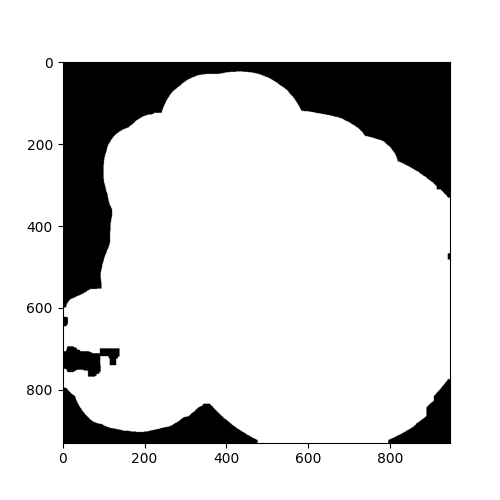

In [36]:
plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap='gray')
plt.show()

In [ ]:

# 1. Load the image
img = image #cropped_img.copy()
# Convert to grayscale (Canny requires single channel)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, threshold1=25, threshold2=50)

# 4. (Optional) Dilate the edges to make them easier to see
kernel = np.ones((3,3), np.uint8)
dilated = cv2.dilate(edges, kernel, iterations=1)

# Display the results
plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(gray, cmap='gray'), plt.title('Original Gray')
plt.subplot(122), plt.imshow(dilated, cmap='gray'), plt.title('Canny Edges')
plt.show()

# Create a kernel (the size determines how far the 'reach' is to connect lines)
kernel = np.ones((15,15), np.uint8)

# 1. Dilate: Makes the white lines thicker to bridge the gaps
thick_edges = cv2.dilate(edges, kernel, iterations=1)

# 2. Closing: Fills small holes inside the boundary
closed_edges = cv2.morphologyEx(thick_edges, cv2.MORPH_CLOSE, kernel)

# 2. THE FILLING STEP: Find and fill the largest hole
contours, _ = cv2.findContours(closed_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create a blank black canvas for our result
solid_mask = np.zeros_like(edges)


# Pick the largest shape (the lettuce)
largest = max(contours, key=cv2.contourArea)
    
    
# DRAW and FILL the shape
cv2.drawContours(solid_mask, [largest], -1, 255, thickness=cv2.FILLED)

    

# Display the results
plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(gray, cmap='gray'), plt.title('Original Gray')
plt.subplot(122), plt.imshow(solid_mask, cmap='gray'), plt.title('Canny Edges')
plt.show()

In [ ]:
# Create a 3D version of the mask or use bitwise_and
# result will be the same size as 'img', but only the lettuce is visible
lettuce_color = cv2.bitwise_and(img, img, mask=solid_mask)

plt.imshow(cv2.cvtColor(lettuce_color, cv2.COLOR_BGR2RGB))
plt.show()